# Cox proportional hazards regression

Survival data records how long until an event and whether the event was even observed before the
study ended (censoring). The Cox model relates covariates to the hazard rate without ever specifying
the baseline hazard, by maximizing a partial likelihood that depends only on the order of events. This
notebook simulates censored survival data with a known effect, fits the Cox model from scratch by
maximizing the partial likelihood, recovers the hazard ratio, checks the proportional-hazards
assumption, and draws covariate-specific survival curves with a Breslow baseline.


## Why the partial likelihood works

The Cox model $h(t\mid x)=h_0(t)\exp(\beta^\top x)$ leaves the baseline hazard $h_0$ completely
unspecified, yet $\beta$ is estimable. The device is the partial likelihood, built from the order in which
events occur.

Theorem (the partial-likelihood score is unbiased). At each event time, the probability that the subject
who failed is the one observed to fail, given the risk set $R(t_i)$, is
$\exp(\beta^\top x_i)/\sum_{j\in R(t_i)}\exp(\beta^\top x_j)$, free of $h_0$. The product of these terms
is the partial likelihood, and its score has mean zero at the true $\beta$, so maximizing it gives a
consistent, asymptotically normal estimator with the usual information-based standard errors.

Proof idea. Conditioning on the risk set and on the fact that exactly one event occurs, the baseline
hazard cancels from numerator and denominator, leaving the multinomial choice probability above. Each
factor is a genuine conditional likelihood contribution, so the summed score is a sum of mean-zero
martingale increments, giving unbiasedness and a martingale central limit theorem for normality.
$\quad\blacksquare$

Counterexample (the proportionality assumption can fail). The whole construction rests on the hazard ratio
between two subjects being constant over time. If the effect of a covariate changes with time (curves that
cross), the proportional-hazards assumption is violated and a single $\beta$ is misleading. The Schoenfeld
residual test in the applied section checks this; time-varying coefficients or stratification are the
remedies.

## 1. Censored survival data

Each subject has a true event time and an independent censoring time; we observe whichever comes
first, plus a flag for which it was. The covariate x raises the hazard by a known coefficient, so the
true hazard ratio per unit of x is exp(beta).


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
rng = np.random.RandomState(0)
n = 1200
x = rng.normal(0, 1, n)
TRUE_BETA = 0.8
lam = 0.1 * np.exp(TRUE_BETA * x)                       # proportional hazards: covariate scales the rate
T = rng.exponential(1 / lam)                            # event times
C = rng.exponential(1 / 0.08, n)                        # independent censoring
time = np.minimum(T, C); event = (T <= C).astype(int)
print('subjects = %d, events observed = %d, censored = %d (%.0f%%)' %
      (n, event.sum(), n - event.sum(), 100 * (1 - event.mean())))
print('true hazard ratio per unit x = exp(%.1f) = %.2f' % (TRUE_BETA, np.exp(TRUE_BETA)))

subjects = 1200, events observed = 631, censored = 569 (47%)
true hazard ratio per unit x = exp(0.8) = 2.23


## 2. The partial likelihood

Cox's insight: at each event time, the probability that the subject who failed was the one to fail,
given the risk set still under observation, depends only on the covariates through exp(beta x), not on
the baseline hazard. Summing the log of these terms over events gives the partial likelihood, which we
maximize for beta.


In [2]:
order = np.argsort(time)
xo, eo = x[order], event[order]
def neg_log_pl(beta):
    eta = beta[0] * xo
    # risk set at each time = all subjects with time >= current (data sorted ascending)
    logcumexp = np.log(np.cumsum(np.exp(eta)[::-1])[::-1])
    return -np.sum(eo * (eta - logcumexp))
res = minimize(neg_log_pl, [0.0], method='BFGS')
bhat = res.x[0]
se = np.sqrt(res.hess_inv[0, 0])
print('estimated beta = %.2f (true %.1f), standard error %.2f' % (bhat, TRUE_BETA, se))
print('estimated hazard ratio = %.2f  (true %.2f)' % (np.exp(bhat), np.exp(TRUE_BETA)))

estimated beta = 0.77 (true 0.8), standard error 0.05
estimated hazard ratio = 2.17  (true 2.23)


## 3. Checking the proportional-hazards assumption

The model rests on the hazard ratio being constant over time. The standard diagnostic uses Schoenfeld
residuals: at each event time, the covariate of the subject who failed minus the risk-set weighted mean
covariate. Under proportional hazards these residuals have no trend with time, so their rank correlation
with the event time is near zero (the Grambsch-Therneau test).


In [3]:
from scipy.stats import spearmanr
exp_eta = np.exp(bhat * xo)
cum_w = np.cumsum(exp_eta[::-1])[::-1]
cum_wx = np.cumsum((exp_eta * xo)[::-1])[::-1]
xbar = cum_wx / cum_w                                   # risk-set weighted mean covariate
schoenfeld = (xo - xbar)[eo == 1]                       # residual at each observed event
event_times = time[order][eo == 1]
rho, pv = spearmanr(schoenfeld, event_times)
print('Schoenfeld residual vs event time: Spearman rho = %.2f, p-value = %.2f' % (rho, pv))
print('rho near 0 with a large p-value supports the proportional-hazards assumption.')

Schoenfeld residual vs event time: Spearman rho = 0.05, p-value = 0.25
rho near 0 with a large p-value supports the proportional-hazards assumption.


## 4. Baseline hazard and survival curves

The Breslow estimator recovers the baseline cumulative hazard from the fitted model. Combining it with
a subject's covariate gives that subject's survival curve, S(t given x) = exp(-H0(t) exp(beta x)).


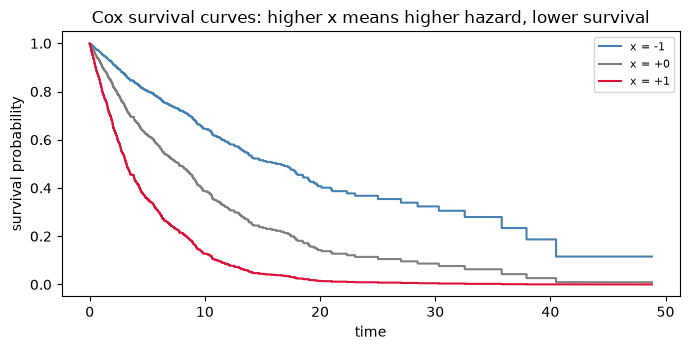

higher x shifts the whole curve down, by a constant factor on the log-hazard scale.


In [4]:
eta = bhat * xo
risk = np.cumsum(np.exp(eta)[::-1])[::-1]
dH0 = np.where(eo == 1, 1.0 / risk, 0.0)                # Breslow increments at event times
H0 = np.cumsum(dH0)
ts = time[order]
fig, ax = plt.subplots(figsize=(7, 3.6))
for xv, c in [(-1.0, 'steelblue'), (0.0, 'gray'), (1.0, 'crimson')]:
    ax.step(ts, np.exp(-H0 * np.exp(bhat * xv)), where='post', color=c, label='x = %+.0f' % xv)
ax.set_xlabel('time'); ax.set_ylabel('survival probability'); ax.legend(fontsize=8)
ax.set_title('Cox survival curves: higher x means higher hazard, lower survival')
plt.tight_layout(); plt.show()
print('higher x shifts the whole curve down, by a constant factor on the log-hazard scale.')

## References

- Cox, D. R. (1972). Regression models and life-tables. JRSS-B.
- Breslow, N. (1974). Covariance analysis of censored survival data. Biometrics.
- Therneau, T. & Grambsch, P. (2000). Modeling Survival Data: Extending the Cox Model. Springer.
- Grambsch, P. & Therneau, T. (1994). Proportional hazards tests and diagnostics based on weighted residuals. Biometrika.


## Exercises

1. Add a second covariate and a categorical group, fit the multivariable Cox model, and interpret each hazard ratio while holding the others fixed.
2. Implement the Schoenfeld residual test for proportional hazards and apply it to data where you deliberately make the effect time-varying; show the test detects the violation.
3. Handle tied event times with the Efron approximation and compare the estimates to the Breslow approximation used here.
4. Compare the Cox partial-likelihood estimate to a fully parametric Weibull accelerated-failure-time model on the same data, and discuss when each is preferable.
